# Did fine-tuning move toward my edits?

Renders the two preference panels for Midi GPT's SFT and DPO checkpoints.

No fine-tuning run in this repo logged its training history, so these are **not**
training curves. Each point is measured after the fact: load a finished checkpoint,
score the clip I kept and the clip I replaced under the conditioning both were
generated with, and see which one the model finds more likely.

The metric definitions live in `utils/metric_utils.py` — read its module docstring
for the method, the chosen/rejected split, and why uncertainty is clustered by section.

In [16]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))   # repo root, so `utils` and `train` import

from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from utils.metric_utils import stage_series, training_runs

%config InlineBackend.figure_formats = ['retina']

## 1. Measure the checkpoints

`stage_series` loads base / ft1 / ft2 / ft3 in turn and scores each on the same set
of pairs. Two sets matter, and they answer different questions:

| set | what it measures |
|---|---|
| `training_runs()` — `training_data/dpo/` | **absorption**: ft2 and ft3 were fit on exactly these |
| a run not used in training | **generalization**: the only honest test of learned taste |

Scoring runs the model over every pair, so this cell takes a little while.

In [17]:
ROLE = "bass"
HELD_OUT = Path("output/0820-142701_a_minor_dark_8bar_ft3")   # never used to train

train = stage_series(ROLE, training_runs())
held_out = stage_series(ROLE, [HELD_OUT])

print(f"{'stage':6}{'logP(edit)':>12}{'logP(orig)':>12}{'margin':>10}{'±SE':>8}{'prefers edit':>14}")
for r in train:
    print(f"  {r.stage:4}{r.chosen:>12.1f}{r.rejected:>12.1f}"
          f"{r.margin:>+10.1f}{r.margin_se:>8.1f}{r.accuracy:>13.0%}")

stage   logP(edit)  logP(orig)    margin     ±SE  prefers edit
  base      -132.9       -73.7     -59.2    26.7          23%
  ft1        -85.4       -48.2     -37.2    41.6          40%
  ft2         -6.9       -43.9     +37.1    12.6          95%
  ft3        -11.1       -82.1     +71.0    19.9         100%


## 2. The rendering function

`plot_preference_shift` draws both panels on **one shared y scale**, which is the
whole point — the two are meant to be compared directly.

Design notes:

- **Colours** are the validated pair `#26699F` / `#C2542B` (CVD ΔE 17.7, chroma and
  contrast both pass). Blue is always the edit, orange always the original.
- **The shaded gap** is filled by whichever clip the model currently prefers, and the
  fill is interpolated on a dense x so the colour switches exactly at the crossing
  rather than snapping to a tick.
- **Bands are ±1 clustered SE.** Each 4-bar section is emitted 12 times transposed,
  and those rows are not independent, so `metric_utils` averages within a section
  before taking the SE across sections. With a single section the SE is `nan` and the
  band is skipped — the held-out panel has n=1 and genuinely has no interval.
- **Position, not colour, carries the polarity**: which line is on top is the finding.

In [35]:
EDIT, ORIG = "#26699F", "#C2542B"          # validated pair: CVD dE 17.7, chroma + contrast pass
INK, MUTED, FAINT, RULE = "#16201F", "#63706E", "#8A9694", "#D5DCDA"
SUBLABEL = {"base": "0 edits", "ft1": "SFT · 4", "ft2": "SFT · 10", "ft3": "DPO"}


def _panel(ax, reports, title, subtitle, ylim, show_bands=True):
    """One panel: log P of the kept clip vs the replaced one, across checkpoints."""
    x = np.arange(len(reports))
    chosen = np.array([r.chosen for r in reports])
    rejected = np.array([r.rejected for r in reports])

    # Shade the gap, coloured by which clip the model currently prefers. Interpolate
    # a dense x so the fill switches colour exactly at the crossing, not at a tick.
    xs = np.linspace(x[0], x[-1], 400)
    ch, rj = np.interp(xs, x, chosen), np.interp(xs, x, rejected)
    ax.fill_between(xs, ch, rj, where=ch >= rj, color=EDIT, alpha=.16,
                    interpolate=True, lw=0, zorder=1)
    ax.fill_between(xs, ch, rj, where=ch < rj, color=ORIG, alpha=.16,
                    interpolate=True, lw=0, zorder=1)

    if show_bands:                          # +/-1 clustered SE; nan when n_sections < 2
        for vals, ses, c in ((chosen, [r.chosen_se for r in reports], EDIT),
                             (rejected, [r.rejected_se for r in reports], ORIG)):
            ses = np.array(ses, dtype=float)
            if not np.isnan(ses).all():
                ses = np.nan_to_num(ses)
                ax.fill_between(x, vals - ses, vals + ses, color=c, alpha=.13, lw=0, zorder=2)

    for vals, c, lbl in ((rejected, ORIG, "rejected"),
                         (chosen, EDIT, "chosen")):
        ax.plot(x, vals, color=c, lw=2, zorder=3, solid_capstyle="round", label=lbl)
        ax.scatter(x, vals, s=42, color=c, zorder=4, edgecolor="white", linewidth=1.6)

    ax.axvline(len(reports) - 1.5, color=RULE, lw=1, zorder=0)   # SFT | DPO divider
    for i, r in enumerate(reports):                              # accuracy row, above the axes
        ax.annotate(f"{r.accuracy:.0%}", (i, 1.02), xycoords=("data", "axes fraction"),
                    ha="center", va="bottom", fontsize=8, color=FAINT, family="monospace")
    ax.annotate("", (0, 1.10), xycoords="axes fraction",
                ha="left", va="bottom", fontsize=7.5, color=FAINT, family="monospace")

    ax.set_xticks(x)
    ax.set_xticklabels([r.stage for r in reports], fontsize=10, family="monospace", color=MUTED)
    for i, r in enumerate(reports):
        ax.annotate(SUBLABEL.get(r.stage, ""), (i, -0.085), xycoords=("data", "axes fraction"),
                    ha="center", va="top", fontsize=7.5, color=FAINT, family="monospace")
    ax.set_xlim(-.28, len(reports) - .72)
    ax.set_ylim(*ylim)
    ax.annotate(title, (0, 1.30), xycoords="axes fraction", ha="left", va="bottom",
                fontsize=11.5, fontweight="bold", color=INK)
    ax.annotate(subtitle, (0, 1.215), xycoords="axes fraction", ha="left", va="bottom",
                fontsize=9, color=MUTED)
    ax.grid(axis="y", color=RULE, lw=1)
    ax.set_axisbelow(True)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0, colors=MUTED, labelsize=8.5)


def plot_preference_shift(train, held_out=None, figsize=(11.4, 4.5), show_bands=True):
    """Two-panel preference chart: training pairs beside a held-out edit.

    `train` / `held_out` are lists of PreferenceReport, one per checkpoint, from
    `metric_utils.stage_series`. Both panels share one y scale so the two are
    directly comparable — the whole point is that they disagree.
    """
    groups = [(train, "SFT", "preference shift")]
    if held_out is not None:
        groups.append((held_out, "One edit it never saw", "held out — not in any training run"))

    allv = [v for g, _, _ in groups for r in g for v in (r.chosen, r.rejected)]
    pad = (max(allv) - min(allv)) * .12
    ylim = (min(allv) - pad, max(allv) + pad)

    fig, axes = plt.subplots(1, len(groups), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (reports, title, subtitle) in zip(axes, groups):
        _panel(ax, reports, title, subtitle, ylim, show_bands)
    axes[0].set_ylabel("mean log P(clip) — higher = more likely",
                       fontsize=8.5, color=MUTED, family="monospace", labelpad=10)
    fig.supxlabel("fine-tuning stage — method · edits used", fontsize=8.5,
                  color=MUTED, family="monospace", y=.035)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labels[::-1], loc="upper center", bbox_to_anchor=(.5, .045),
               ncol=2, frameon=False, fontsize=8.5, labelcolor=MUTED, handlelength=1.6)
    fig.subplots_adjust(top=.76, bottom=.24, wspace=.08)
    return fig

## 3. Render

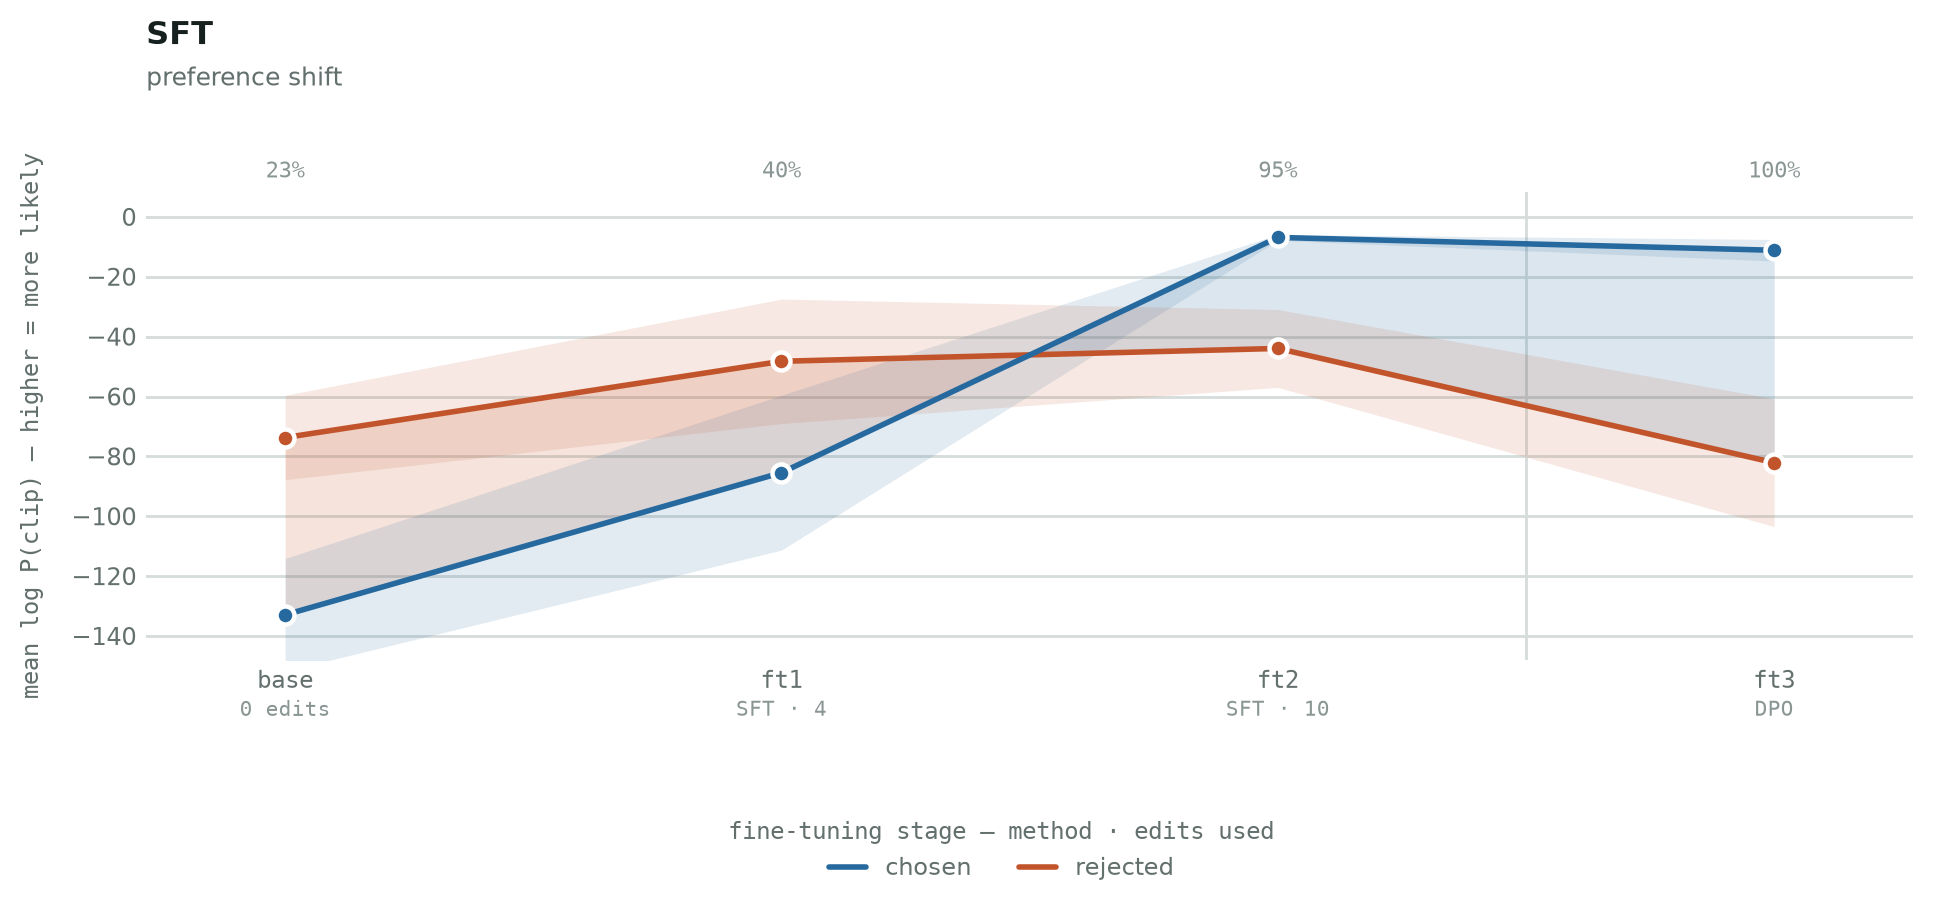

In [36]:
fig = plot_preference_shift(train)
fig.savefig("images/preference-shift-notebook.png", dpi=170,
            bbox_inches="tight", facecolor="white")
fig;

## 4. Reading it

**Left — it moved, a long way.** The base model scores my edit below the clip it
wrote itself and picks the original in 77% of pairs. By ft2 my edit sits near zero
and the model prefers it in 95%. Since ft1 and ft2 both branch off base, that is a
clean comparison rather than a chain.

**Right — it did not transfer.** On the one edit held out of training, the original
stays on top at every stage and preference accuracy is 0% throughout. What the left
panel measures is absorption of ten specific clips. One held-out section is thin
evidence, but it is the only held-out edit that exists, and it points the wrong way.

**How the margin grew differs by method.** SFT lifted the chosen side
(−132.9 → −6.9) and left the rejected side roughly alone. DPO barely moved the
chosen side and widened the gap by pushing the rejected side *down*
(−43.9 → −82.1) — the suppression case the DPO loss splits its margin to detect.

**What the error bands say.** Only `base → ft2` clears 2 SE (3.3 SE). `base → ft1`
is 0.45 SE and `ft2 → ft3` is 1.44 SE — both within noise. The headline result holds;
the intermediate steps are not individually resolved at ten edited sections.

In [20]:
for a, b in (("base", "ft1"), ("base", "ft2"), ("ft2", "ft3")):
    ra = next(r for r in train if r.stage == a)
    rb = next(r for r in train if r.stage == b)
    d = rb.margin - ra.margin
    se = (ra.margin_se ** 2 + rb.margin_se ** 2) ** 0.5
    verdict = "resolved" if abs(d) > 2 * se else "within noise"
    print(f"{a:>5} -> {b:<5} {d:+8.1f} ± {se:5.1f}  = {abs(d)/se:.2f} SE   {verdict}")

 base -> ft1      +22.0 ±  49.5  = 0.45 SE   within noise
 base -> ft2      +96.3 ±  29.5  = 3.26 SE   resolved
  ft2 -> ft3      +33.9 ±  23.5  = 1.44 SE   within noise
